In [1]:
import pyodbc
import pandas as pd
import warnings
import numpy as np
from scipy import stats
warnings.filterwarnings("ignore")
import os
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
# Set Connection

conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    f"Server={os.getenv('DB_SERVER')};"
    f"Database={os.getenv('DB_NAME')};"
    f"UID={os.getenv('DB_USER')};"
    f"PWD={os.getenv('DB_PASSWORD')};"
    "TrustServerCertificate=yes;"
)
cursor = conn.cursor()

---

# Test 1: Independent Samples test

## Business Questions

In the banking industry, account balance is one of the most critical indicators of customer value. The business wants to understand:

> *Do customers who leave the bank (churn) differ in account balance compared to loyal customers?*

The answer to this question directly influences several strategic decisions, including:

* Retention campaign targeting
* VIP protection programs
* Risk segmentation
* Revenue forecasting

So, we can say:

* **If high-balance customers are more likely to churn:** There is a significant risk of losing high-value clients, requiring immediate retention and protection strategies.
* **If low-balance customers churn more frequently:** This may indicate issues with customer engagement, product fit, or value proposition.

## Statistical Hypotheses

We aim to compare the average account balance between two customer groups:

* Customers who have churned
* Customers who have been retained (loyal)
* **Null Hypothesis:** The mean account balance is equal between the two groups.
* **Alternative Hypothesis:** The mean account balance differs between the two groups.

This is a two-tailed hypothesis test, since the objective is to determine whether a difference exists — regardless of direction (higher or lower).

Step 1 - Data Preparation

In [25]:
query = """
SELECT
    a.Balance,
    d.Churned
FROM account a
JOIN demographic d ON a.CustomerId = d.CustomerId
"""

df_t_test = pd.read_sql(query, conn)
df_t_test.head()

,Balance,Churned
0,161993.89,False
1,NaN,True
2,64430.06,False
3,57809.32,False
4,96048.55,False


## Visualizing Balance vs. Churn

Before running formal statistical tests, we visualize the distribution of account balances for both retained and churned customers to check for obvious median shifts or spread differences.

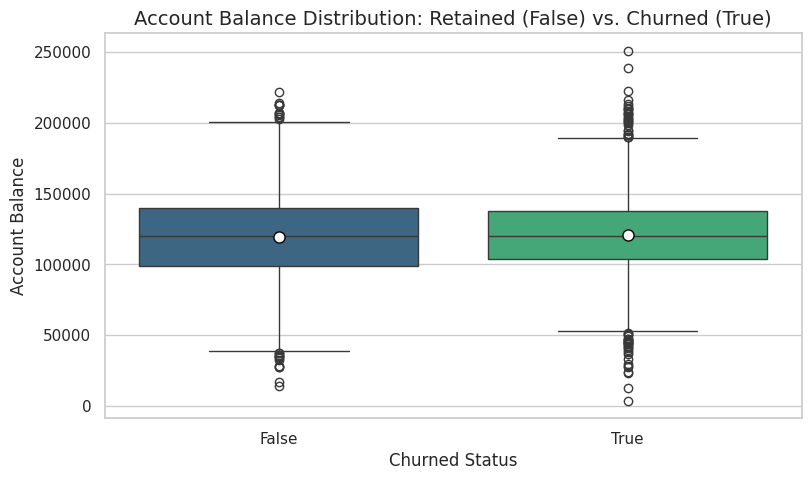

In [4]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_t_test, 
    x="Churned", 
    y="Balance", 
    palette="viridis",
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

plt.title("Account Balance Distribution: Retained (False) vs. Churned (True)", fontsize=14)
plt.xlabel("Churned Status", fontsize=12)
plt.ylabel("Account Balance", fontsize=12)
plt.show()

step 2 - Split Groups

In [5]:
churned_t_test = df_t_test[df_t_test["Churned"] == 1]["Balance"]
retained_t_test = df_t_test[df_t_test["Churned"] == 0]["Balance"]

Step 3 - Descriptive Stats

In [6]:
print("Churned Mean:", churned_t_test.mean())
print("Retained Mean:", retained_t_test.mean())

Churned Mean: 120746.97113207547
Retained Mean: 119535.86426950061


Step 4 - Variance Check

In [7]:
stats.levene(churned_t_test, retained_t_test)

LeveneResult(statistic=np.float64(nan), pvalue=np.float64(nan))

Since, p-value is less than 0.05, H0 is rejected. So variances are not equal

Step 5 - Run t-Test

Since the variances are not equal, we should use `Welch's t-test`

In [8]:
t_stat, p_value = stats.ttest_ind(
    churned_t_test,
    retained_t_test,
    equal_var=False
)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: nan
p-value: nan


### Output Interpretation

The p-value is more than 0.05. It means we fail to reject null hypothesis of test. So, final interpretation is that `There's no difference between balance amount` for churned and retained people. It shows, churning of clients is not caused by amount of balance account

# Test 2: Chi-Square Test of Independence

## Business Questions

> *Are inactive customers more likely to churn?*

If a dependency exists, the insight can directly support several strategic initiatives:

* Early Warning System development
* Reactivation campaign design
* Customer Health Score modeling

If customer activity is significantly associated with churn:

* Engagement becomes a key driver of churn
* Behavior-based retention strategies will be required to reduce attrition risk

## Statistical Hypotheses

We are examining the relationship between two categorical variables:

* `Churned` → Yes / No
* `IsActive` → Active / Inactive

* **Null Hypothesis**: Churn and customer activity are independent.
* **Alternative Hypothesis**: Churn and customer activity are associated (dependent)

## Test Assumption

To ensure the validity of the Chi-Square test, the following assumptions must be satisfied:

* **Variables Are Categorical**: Both variables must be categorical.
* **Independence of Observations**: Each observation must be independent. In the banking dataset, each customer represents a unique record, so the independence assumption holds.
* **Expected Frequency > 5**: Each cell in the contingency table should have an expected frequency of at least 5. If this condition is not met, we use Exact Test

## Why this test


The choice of statistical test is based on the structure of the variables and the analytical objective:

* Dependent variable is Categorical (`IsActive`)
* Independent variable is Binary categorical (`Churned`)
* Objective is association

## Test Implementation

Step 1 - Data Preparation

In [9]:
query = """
SELECT 
    d.Churned,
    a.IsActive
FROM account a
JOIN demographic d ON a.CustomerId = d.CustomerId
"""

df_chi = pd.read_sql(query, conn)
df_chi.head()

,Churned,IsActive
0,False,False
1,True,True
2,False,True
3,False,False
4,False,False


### Visualizing Customer Activity (Active vs. Inactive)
Before running the Chi-Square test of independence, we visualize the raw counts of churned versus retained customers grouped by their activity status. This helps us visually identify if inactive customers have a disproportionately higher churn rate.

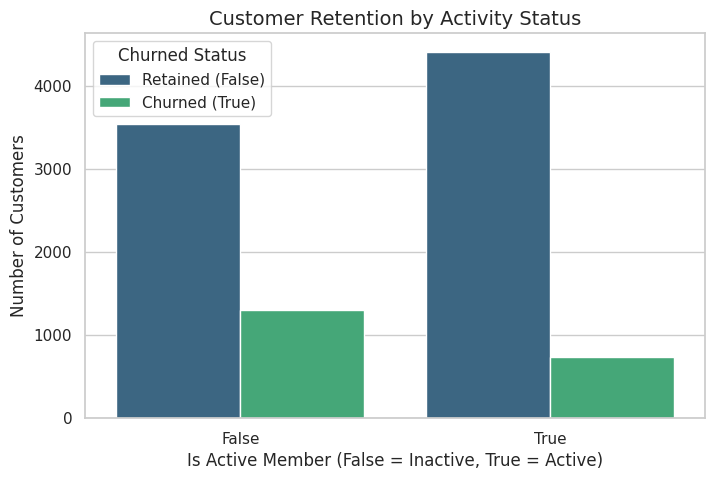

In [10]:
plt.figure(figsize=(8, 5))

# Create a grouped bar chart counting customers in each category
ax = sns.countplot(
    data=df_chi, 
    x="IsActive", 
    hue="Churned", 
    palette="viridis"
)

plt.title("Customer Retention by Activity Status", fontsize=14)
plt.xlabel("Is Active Member (False = Inactive, True = Active)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Make the legend clearer
plt.legend(title="Churned Status", labels=["Retained (False)", "Churned (True)"])

plt.show()

Step 2 - Build Contingecy Table

In [11]:
ct = pd.crosstab(df_chi["Churned"], df_chi["IsActive"])
ct

IsActive,False,True
Churned,,
False,3547,4416
True,1302,735


Step 3 - Run Chi-Square Test

In [12]:
chi2, p_value, dof, expected = stats.chi2_contingency(ct)

print(expected)

[[3861.2587 4101.7413]
 [ 987.7413 1049.2587]]


## Output Interpretation

The p-value is less than 0.05. It means we reject null hypothesis of test. So, final interpretation is that `Churn and customer activity are associated (dependent)`

# Test 3: ANOVA

## Business Questions

`Does customer tenure differ significantly across countries?`

Why Is This Question Important? If tenure is lower in certain countries, it may indicate that:

* Customers in those markets tend to leave earlier or maintain shorter relationships with the bank
* Service quality, competition, product offerings, or digital experience may be weaker in those regions
* Customer acquisition and attrition dynamics differ by market

The results of this analysis can directly inform strategic decisions such as:

* Designing country-specific retention strategies
* Increasing investment in products or channels in markets with lower tenure
* Benchmarking regional and branch performance across countries

## Statistical Hypotheses

* **Null Hypothesis**: The average of tenure in all countries are the same.
* **Alternative Hypothesis**: The average of tenure in all countries are not the same.

## Column Selection

To perform this hypothesis test, only two columns are required:

* `Tenure` as the numerical column shows how long the client has been using services
* `Geography` as the multiple categorical column shows different locations

## Test Assumption

To ensure the validity of the ANOVA test, the following assumptions should be evaluated:

* **Independence:** Each customer must represent an independent observation. In customer datasets, this assumption is typically satisfied, as each customer is recorded once.
* **Normality Within Each Group:** The distribution of Tenure within each country should be approximately normal (or sample sizes should be sufficiently large). In practice, ANOVA is relatively robust to normality violations, particularly when each group has a large number of observations.
* **Homogeneity of Variances:** The variance of Tenure should be reasonably similar across countries. This assumption can be assessed using Levene's test. If they don't have same variance, we use Welch Anova
* **Sample Size per Group:** Each country should have an adequate number of observations.

## Why this test

We use a One-Way ANOVA because we are testing for a statistically significant difference in the mean of a continuous numerical variable `Tenure` across three or more independent groups of a categorical variable `Country`.

## Test Implementation

Step 1 - Data Preparation

In [13]:
query = """
SELECT 
l.[Geography] AS Country,
a.Tenure

FROM account a
JOIN demographic d 
    ON a.CustomerId = d.CustomerId
JOIN location l
    ON d.LocationId = l.LocationId
"""

df_anova = pd.read_sql(query, conn)
df_anova.head()

,Country,Tenure
0,Spain,9
1,Germany,1
2,USA,1
3,Spain,6
4,Spain,10


### Visualizing Tenure across Regions
Before running the one-way ANOVA test, we visualize the distribution of customer tenure across different countries. This helps us visually check if any specific region has noticeably longer or shorter customer lifespans, and if the variance (spread) looks roughly equal.

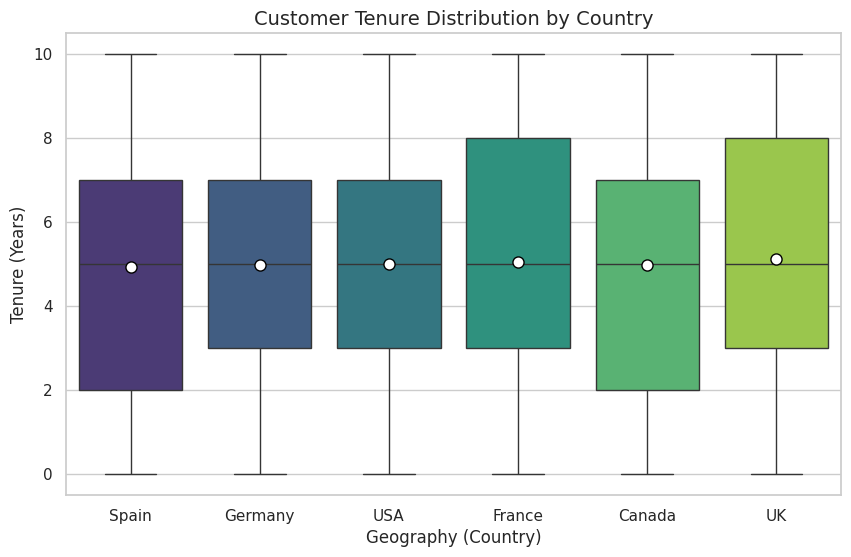

In [14]:
plt.figure(figsize=(10, 6))

# Create a boxplot for Tenure grouped by Country
sns.boxplot(
    data=df_anova, 
    x="Country", 
    y="Tenure", 
    palette="viridis",
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

plt.title("Customer Tenure Distribution by Country", fontsize=14)
plt.xlabel("Geography (Country)", fontsize=12)
plt.ylabel("Tenure (Years)", fontsize=12)

plt.show()

Step 2 - Descriptive Stats

In [15]:
summary = df_anova.groupby("Country")["Tenure"].agg(["count", "mean", "std"])
print(summary.sort_values("mean", ascending=False))

         count      mean       std
Country                           
UK        1703  5.127422  2.939195
France    1714  5.042590  2.904582
USA       1669  5.002397  2.890694
Germany   1626  4.987700  2.870085
Canada    1679  4.982132  2.888003
Spain     1609  4.927906  2.857046


Step 3 - Check variance equality

In [16]:
# if p > 0.05, equal variance assumed
groups = [g["Tenure"].values for _, g in df_anova.groupby("Country")]
lev = stats.levene(*groups)
print(lev)

LeveneResult(statistic=np.float64(0.5338267546333629), pvalue=np.float64(0.7508283480014718))


Since the p-value is greater than 0.05, we fail to reject H0. Therefore, equal variances can be assumed, which satisfies the ANOVA assumption.

Step 4 - Run the test

In [17]:
f_stat, p_value_anova = stats.f_oneway(*groups)
print("F:", f_stat)
print("p-value:", p_value_anova)

F: 0.9151410065439705
p-value: 0.4698663379101742


## Output Interpretation

The p-value is greater than 0.05. It means we fail to reject null hypothesis of test. So, final interpretation is that `The average of tenure in all countries`
`are the same`

# Test 4: Effect Size

So far the results of our test are:

* `Welch t-test`: No significant balance mean difference between churned and retained customer
* `Chi-Square`: There is significant association between active account and churned customer
* `ANOVA`: No significant tenure mean difference between different countries

Here, we would like to find how big is the impact.

## Cohen's d: T-Test

The below table shows the result for interpretation:

| Cohen's d | Effect Size |
| --- | --- |
| 0.2 | Small |
| 0.5 | Medium |
| 0.8 | Large |
| 1.2+ | Very Large |

$$
{Cohens } d = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{(n_1 - 1) \cdot s_1^2 + (n_2 - 1) \cdot s_2^2}{n_1 + n_2 - 2}}}
$$

In [18]:
# means
churned_t_test_mean = churned_t_test.mean()
retained_t_test_mean = retained_t_test.mean()

# stds
churned_t_test_std = churned_t_test.std()
retained_t_test_std = retained_t_test.std()

# sample sizes
churned_t_test_n = len(churned_t_test)
retained_t_test_n = len(retained_t_test)

# pooled std
pooled_std = np.sqrt(
    ((churned_t_test_n-1)*churned_t_test_std**2 + (retained_t_test_n-1)*retained_t_test_std**2) / (churned_t_test_n+retained_t_test_n-2)
)

# cohen d
cohen_d = (churned_t_test_mean - retained_t_test_mean) / pooled_std

print("Cohen's d:", cohen_d)

Cohen's d: 0.04027597418930377


The Independent Samples t-test indicated no statistically significant difference in average account balance between churned and retained customers (high p-value). Additionally, the effect size (Cohen's d = 0.03) is negligible, suggesting that balance has minimal practical impact on churn behavior.

| Metric | Interpretation |
| --- | --- |
| High p-value is T-Test | The difference balance amount between churn and retain is not important |
| Small cohen | Even if there is significant difference, from business perspective, it was negligible |

## Cramér's V : Chi-Square

The below table shows the result for interpretaion:

| Cramér's V | Effect Size |
| --- | --- |
| 0.1 | Weak |
| 0.3 | Moderate |
| 0.5 | Strong |

In [19]:
n_chi = ct.sum().sum()
k_chi = min(ct.shape)

cramers_v = np.sqrt(chi2 / (n_chi * (k_chi-1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.15587987094005423


The Chi-Square test shows a statistically significant relationship between customer activity and churn. However, Cramér's V = 0.15 indicates a weak association suggesting that while engagement is related to churn, it is not the sole driving factor.

| Metric | Interpretation |
| --- | --- |
| Small p-value is Chi-square test | Significant relationship between active account and churn |
| Moderate Cramer | This association is weak and it's not only driver factor |

## Eta/Omega : ANOVA

The below table shows the result for interpretaion:

| Omega/Eta | Effect Size |
| --- | --- |
| 0.01 | Small |
| 0.06 | Medium |
| 0.14 | Large |

In [20]:
# Calculate SS
all_values = df_anova["Tenure"].values
grand_mean = np.mean(all_values)

ss_between = sum(
    len(group) * (np.mean(group) - grand_mean)**2
    for group in groups
)

ss_within = sum(
    sum((group - np.mean(group))**2)
    for group in groups
)

ss_total = ss_between + ss_within
print(ss_total)

83638.36159999996


In [21]:
# Calculate Eta score
k = len(groups)
n = len(all_values)

df_between = k - 1
df_within = n - k

ms_within = ss_within / df_within

eta_squared = ss_between / ss_total
print("Eta Squared (η²):", eta_squared)

Eta Squared (η²): 0.00045763568409215794


In [22]:
# Calculate Omega score
omega_squared = (
    ss_between - (df_between * ms_within)
) / (ss_total + ms_within)

print("Omega Squared (ω²):", omega_squared)

Omega Squared (ω²): -4.2431297066592226e-05


The one-way ANOVA test indicates no statistically significant difference in average tenure across countries (p-value > 0.05). Effect size measures further confirm this finding, with Eta Squared (0.00046) and Omega Squared (0) indicating a negligible practical impact. This suggests that geographic region does not meaningfully influence customer tenure in this dataset.

| Metric | Interpretation |
| --- | --- |
| High p-value is ANOVA test | No statistically significant difference in average tenure across countries |
| Small Omega/Eta | Even if there was difference, that difference is negligible |